In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [23]:
data = {
    "Age": [22,25,28,35,40,30,27,45,50,29],
    "Salary": [25000,30000,35000,50000,65000,40000,32000,70000,80000,38000],
    "Experience": [1,2,3,8,12,5,3,15,20,4],
    "Department": ["IT","HR","IT","Finance","IT",
                   "HR","Finance","IT","Finance","HR"],
    "Promotion": [0,0,0,1,1,0,0,1,1,0]
}


In [24]:
df = pd.DataFrame(data)
print(df)

   Age  Salary  Experience Department  Promotion
0   22   25000           1         IT          0
1   25   30000           2         HR          0
2   28   35000           3         IT          0
3   35   50000           8    Finance          1
4   40   65000          12         IT          1
5   30   40000           5         HR          0
6   27   32000           3    Finance          0
7   45   70000          15         IT          1
8   50   80000          20    Finance          1
9   29   38000           4         HR          0


In [25]:
encoder = LabelEncoder()

In [26]:

df["Department"] = encoder.fit_transform(df["Department"])
print(df)

   Age  Salary  Experience  Department  Promotion
0   22   25000           1           2          0
1   25   30000           2           1          0
2   28   35000           3           2          0
3   35   50000           8           0          1
4   40   65000          12           2          1
5   30   40000           5           1          0
6   27   32000           3           0          0
7   45   70000          15           2          1
8   50   80000          20           0          1
9   29   38000           4           1          0


In [27]:

X = df[["Age", "Salary", "Experience", "Department"]]
y = df["Promotion"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [29]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [30]:
knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [31]:
knn_pred = knn_model.predict(X_test_scaled)

print(knn_pred)

[1 0]


In [32]:
knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy")

print(knn_accuracy)

KNN Accuracy
1.0


In [33]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [34]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [35]:
rf_pred = rf_model.predict(X_test)

print(rf_pred)

[1 0]


In [36]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy")

print(rf_accuracy)

Random Forest Accuracy
1.0


In [37]:
param_grid = {
    'n_neighbors': [1,3,5,7]
}

In [38]:
grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=3
)

In [39]:
grid.fit(X_train_scaled, y_train)

c:\Users\jagad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\jagad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jagad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jagad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 764, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
                             ^^^^^^^^^^^^^^^
  F

GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 3, 5, 7]})

In [40]:
print(grid.best_params_)

print(grid.best_score_)

{'n_neighbors': 1}
0.8333333333333334


In [46]:
new_employee = pd.DataFrame(
    [[32, 45000, 6, 2]],
    columns=["Age", "Salary", "Experience", "Department"]
)

new_employee_scaled = scaler.transform(new_employee)

prediction = knn_model.predict(new_employee_scaled)

print(prediction)

[0]


In [42]:
prediction = knn_model.predict(new_employee_scaled)

print(prediction)

[0]


In [43]:
if prediction[0] == 1:
    print("Promotion Possible")
else:
    print("No Promotion")

No Promotion


In [44]:
cm = confusion_matrix(y_test, knn_pred)

print(cm)

[[1 0]
 [0 1]]


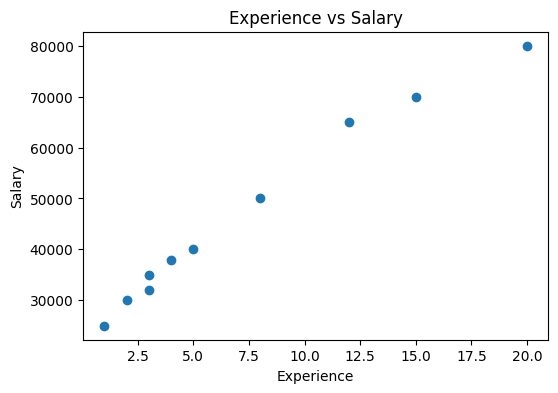

In [45]:
plt.figure(figsize=(6,4))

plt.scatter(df["Experience"], df["Salary"])

plt.xlabel("Experience")

plt.ylabel("Salary")

plt.title("Experience vs Salary")

plt.show()